# Potential Talents Candidate Ranking Algorithm

As a talent sourcing and management company, we are interested in finding talented individuals for sourcing these candidates to technology companies. Finding talented candidates is not easy, for several reasons. The first reason is one needs to understand what the role is very well to fill in that spot, this requires understanding the client’s needs and what they are looking for in a potential candidate. The second reason is one needs to understand what makes a candidate shine for the role we are in search for. Third, where to find talented individuals is another challenge.

The nature of our job requires a lot of human labor and is full of manual operations. Towards automating this process we want to build a better approach that could save us time and finally help us spot potential candidates that could fit the roles we are in search for. Moreover, going beyond that for a specific role we want to fill in we are interested in developing a machine learning powered pipeline that could spot talented individuals, and rank them based on their fitness.

We are right now semi-automatically sourcing a few candidates, therefore the sourcing part is not a concern at this time but we expect to first determine best matching candidates based on how fit these candidates are for a given role. We generally make these searches based on some keywords such as “full-stack software engineer”, “engineering manager” or “aspiring human resources” based on the role we are trying to fill in. These keywords might change, and you can expect that specific keywords will be provided to you.

Assuming that we were able to list and rank fitting candidates, we then employ a review procedure, as each candidate needs to be reviewed and then determined how good a fit they are through manual inspection. This procedure is done manually and at the end of this manual review, we might choose not the first fitting candidate in the list but maybe the 7th candidate in the list. If that happens, we are interested in being able to re-rank the previous list based on this information. This supervisory signal is going to be supplied by starring the 7th candidate in the list. Starring one candidate actually sets this candidate as an ideal candidate for the given role. Then, we expect the list to be re-ranked each time a candidate is starred.

Data Description:

The data comes from our sourcing efforts. We removed any field that could directly reveal personal details and gave a unique identifier for each candidate.

Attributes:
id : unique identifier for candidate (numeric)

job_title : job title for candidate (text)

location : geographical location for candidate (text)

connections: number of connections candidate has, 500+ means over 500 (text)

Output (desired target):
fit - how fit the candidate is for the role? (numeric, probability between 0-1)

Keywords: “Aspiring human resources” or “seeking human resources”


In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from nltk.tokenize import word_tokenize
from gensim.downloader import load

df = pd.read_csv(
    r"C:\Users\Dillo\Potential-Talents-Candidate-Ranking-Model\data\potential-talents - Aspiring human resources - seeking human resources.csv"
)

In [54]:
print(df.duplicated().sum())

0


In [55]:
print(df.head())

   id                                          job_title  \
0   1  2019 C.T. Bauer College of Business Graduate (...   
1   2  Native English Teacher at EPIK (English Progra...   
2   3              Aspiring Human Resources Professional   
3   4             People Development Coordinator at Ryan   
4   5    Advisory Board Member at Celal Bayar University   

                              location connection  fit  
0                       Houston, Texas         85  NaN  
1                               Kanada      500+   NaN  
2  Raleigh-Durham, North Carolina Area         44  NaN  
3                        Denton, Texas      500+   NaN  
4                       İzmir, Türkiye      500+   NaN  


In [56]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          104 non-null    int64  
 1   job_title   104 non-null    object 
 2   location    104 non-null    object 
 3   connection  104 non-null    object 
 4   fit         0 non-null      float64
dtypes: float64(1), int64(1), object(3)
memory usage: 4.2+ KB
None


In [57]:
print(df.shape)

(104, 5)


In [58]:
print(df.dtypes)

id              int64
job_title      object
location       object
connection     object
fit           float64
dtype: object


In [59]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,104.0,NaN,NaN,NaN,52.5,30.166206,1.0,26.75,52.5,78.25,104.0
job_title,104,52,2019 C.T. Bauer College of Business Graduate (...,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location,104,41,Kanada,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
connection,104,33,500+,44,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fit,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


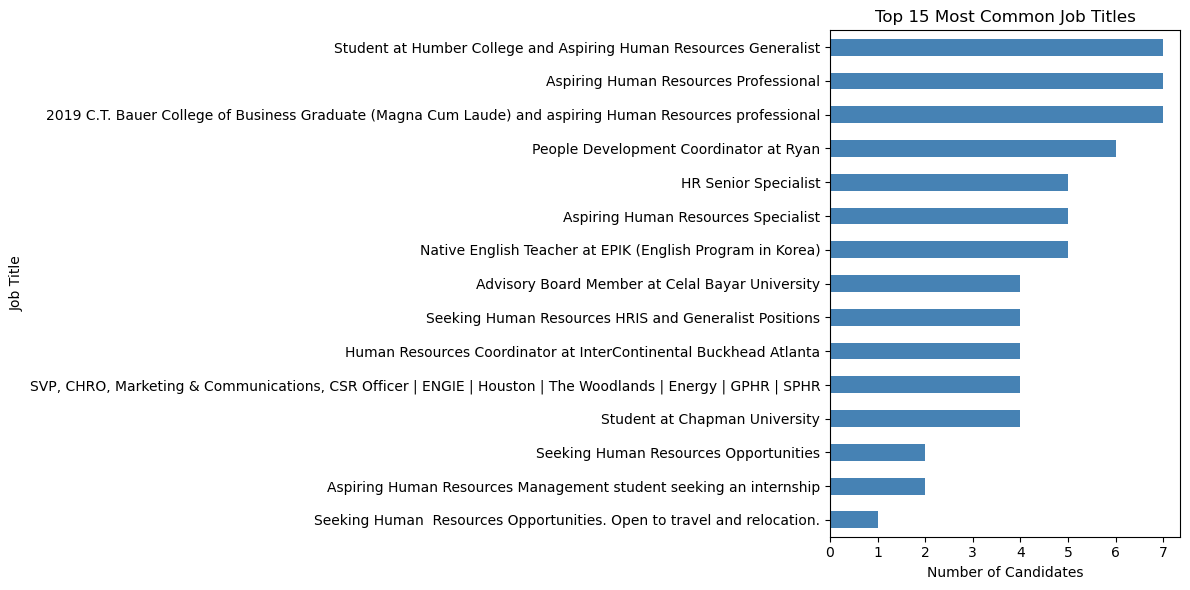

In [60]:
top_titles = df["job_title"].value_counts().head(15)

plt.figure(figsize=(12,6))

top_titles.sort_values().plot(
    kind="barh",
    color="steelblue"
)

plt.title("Top 15 Most Common Job Titles")
plt.xlabel("Number of Candidates")
plt.ylabel("Job Title")

plt.tight_layout()
plt.show()

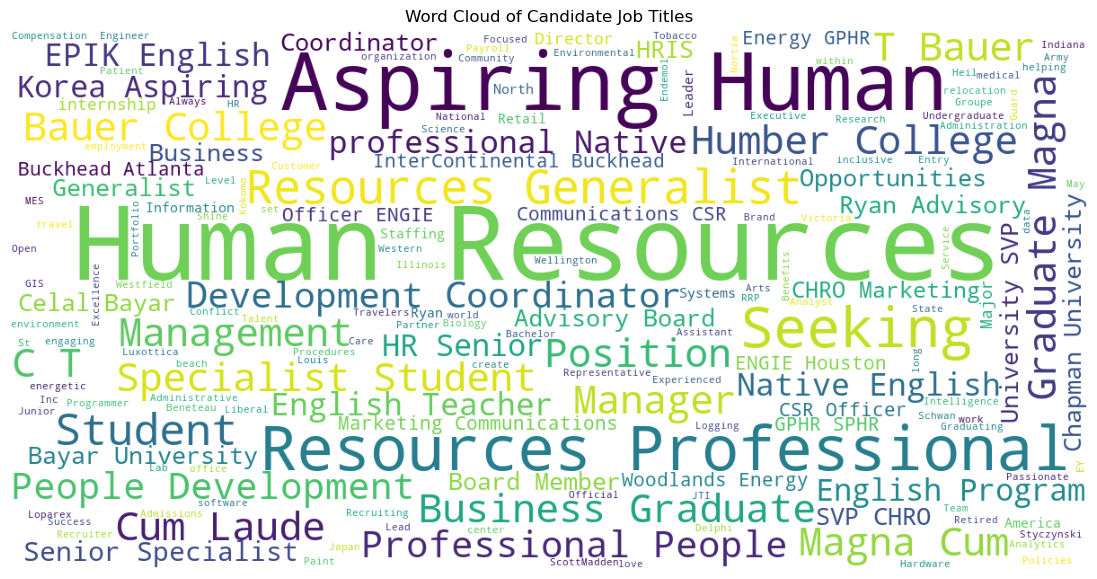

In [61]:
text = " ".join(df["job_title"].astype(str))

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(text)

plt.figure(figsize=(14,7))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud of Candidate Job Titles")
plt.show()

,Word,Frequency
0,human,63
1,resources,63
2,aspiring,35
3,professional,20
4,student,16
5,seeking,15
6,college,14
7,generalist,14
8,university,12
9,specialist,12


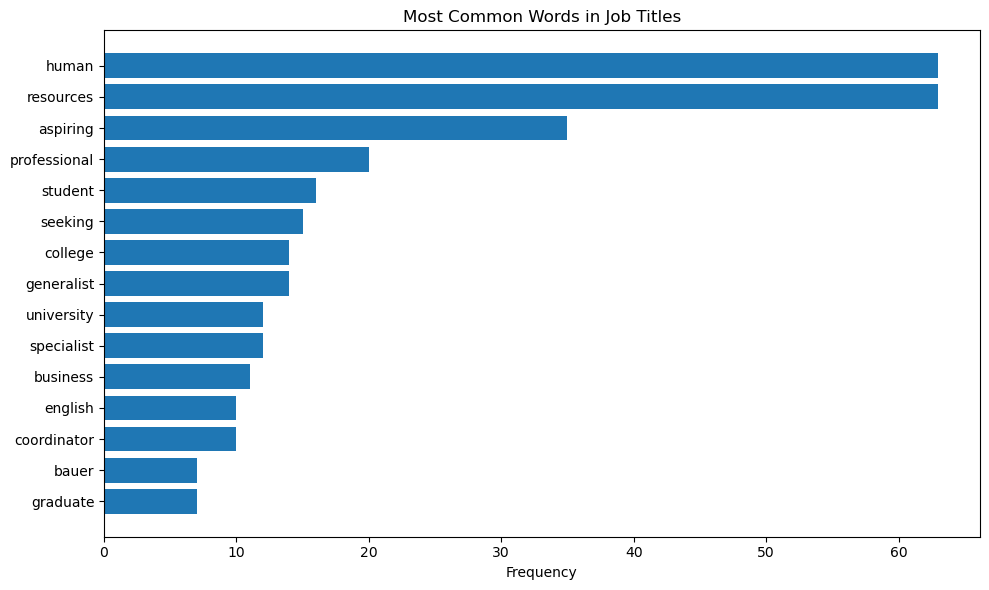

In [62]:
words = []

for title in df["job_title"]:
    words.extend(re.findall(r"[A-Za-z]+", title.lower()))

# Remove common filler words
stop_words = {
    "and",
    "of",
    "the",
    "to",
    "for",
    "in",
    "with",
    "a",
    "an",
    "at",
    "c",
    "t",
}

words = [word for word in words if word not in stop_words]

common_words = Counter(words).most_common(15)

common_df = pd.DataFrame(
    common_words,
    columns=["Word", "Frequency"]
)

display(common_df)

plt.figure(figsize=(10,6))

plt.barh(common_df["Word"], common_df["Frequency"])

plt.gca().invert_yaxis()

plt.title("Most Common Words in Job Titles")
plt.xlabel("Frequency")

plt.tight_layout()
plt.show()

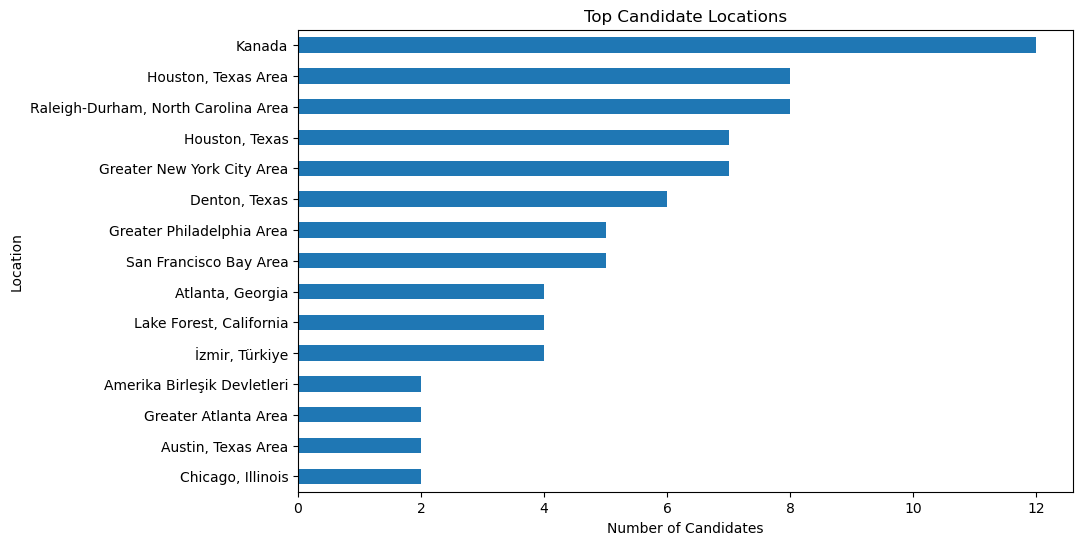

In [63]:
location_counts = (
    df["location"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(10,6))

location_counts.sort_values().plot(kind="barh")

plt.title("Top Candidate Locations")
plt.xlabel("Number of Candidates")
plt.ylabel("Location")

plt.show()

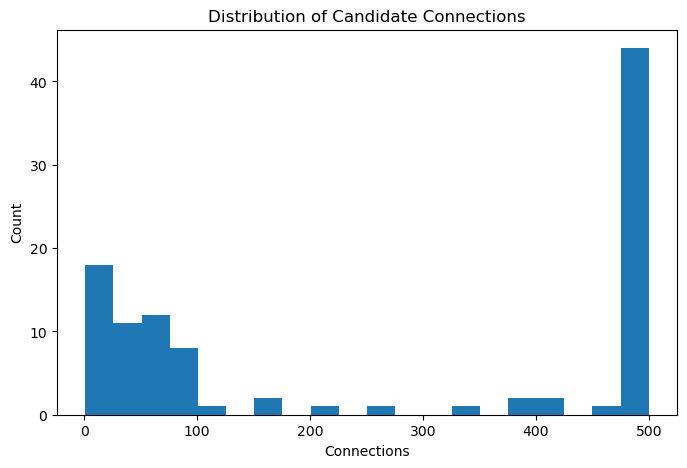

In [64]:
df["connections_numeric"] = (
    df["connection"]
    .astype(str)
    .str.replace("+", "", regex=False)
    .astype(int)
)

plt.figure(figsize=(8,5))

plt.hist(df["connections_numeric"], bins=20)

plt.title("Distribution of Candidate Connections")
plt.xlabel("Connections")
plt.ylabel("Count")

plt.show()

## Models

### TF-IDF

In [65]:
search_query = "Aspiring human resources seeking human resources"

In [66]:
documents = df["job_title"].tolist() + [search_query]

vectorizer = TfidfVectorizer(
    stop_words="english",
    lowercase=True
)

tfidf_matrix = vectorizer.fit_transform(documents)

In [67]:
candidate_vectors = tfidf_matrix[:-1]
query_vector = tfidf_matrix[-1]

In [68]:
similarity_scores = cosine_similarity(
    candidate_vectors,
    query_vector
).flatten()

In [69]:
df["similarity_score"] = similarity_scores

In [70]:
ranked_candidates = (
    df.sort_values(
        by="similarity_score",
        ascending=False
    )
    .reset_index(drop=True)
)

ranked_candidates.head(10)

,id,job_title,location,connection,fit,connections_numeric,similarity_score
0,73,"Aspiring Human Resources Manager, seeking inte...","Houston, Texas Area",7,NaN,7,0.704671
1,97,Aspiring Human Resources Professional,"Kokomo, Indiana Area",71,NaN,71,0.612985
2,58,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,NaN,44,0.612985
3,17,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,NaN,44,0.612985
4,46,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,NaN,44,0.612985
5,33,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,NaN,44,0.612985
6,21,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,NaN,44,0.612985
7,3,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,NaN,44,0.612985
8,30,Seeking Human Resources Opportunities,"Chicago, Illinois",390,NaN,390,0.577505
9,28,Seeking Human Resources Opportunities,"Chicago, Illinois",390,NaN,390,0.577505


In [71]:
ranked_candidates[
    ["id", "job_title", "location", "connection", "similarity_score"]
].head(20)

,id,job_title,location,connection,similarity_score
0,73,"Aspiring Human Resources Manager, seeking inte...","Houston, Texas Area",7,0.704671
1,97,Aspiring Human Resources Professional,"Kokomo, Indiana Area",71,0.612985
2,58,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.612985
3,17,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.612985
4,46,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.612985
5,33,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.612985
6,21,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.612985
7,3,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.612985
8,30,Seeking Human Resources Opportunities,"Chicago, Illinois",390,0.577505
9,28,Seeking Human Resources Opportunities,"Chicago, Illinois",390,0.577505


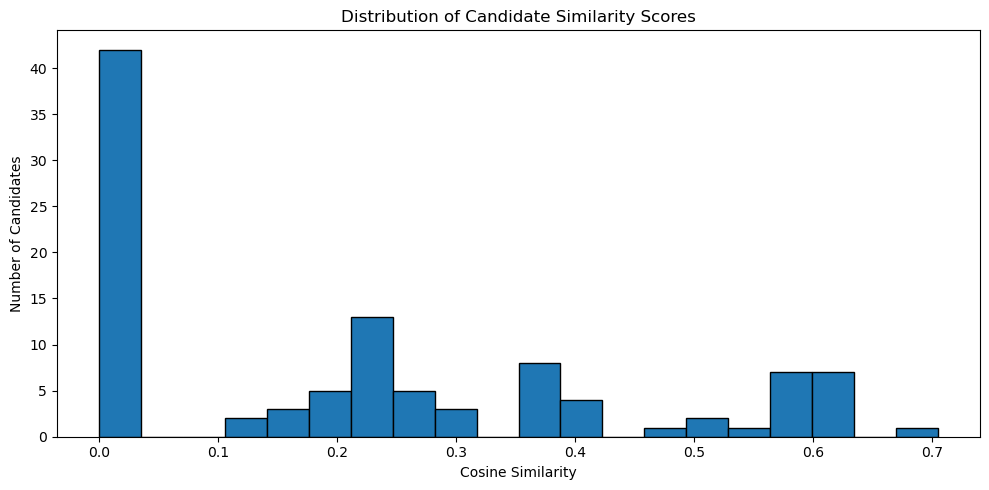

In [72]:
plt.figure(figsize=(10, 5))

plt.hist(df["similarity_score"], bins=20, edgecolor="black")

plt.title("Distribution of Candidate Similarity Scores")
plt.xlabel("Cosine Similarity")
plt.ylabel("Number of Candidates")

plt.tight_layout()
plt.show()

### Word2Vec

In [73]:
def get_document_vector(text, model):
    words = word_tokenize(text.lower())

    vectors = [
        model[word]
        for word in words
        if word in model
    ]

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)

In [74]:
import nltk

nltk.download("punkt_tab")

candidate_vectors = np.vstack(
    df["job_title"].apply(
        lambda x: get_document_vector(x, w2v)
    )
)

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Dillo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [75]:
search_query = "Aspiring Human Resources"

query_vector = get_document_vector(
    search_query,
    w2v
).reshape(1, -1)

In [76]:
similarity_scores = cosine_similarity(
    candidate_vectors,
    query_vector
).flatten()

In [77]:
df["word2vec_similarity"] = similarity_scores

ranked_candidates = (
    df
    .sort_values(
        by="word2vec_similarity",
        ascending=False
    )
    .reset_index(drop=True)
)

ranked_candidates.head(20)

,id,job_title,location,connection,fit,connections_numeric,similarity_score,word2vec_similarity
0,46,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,NaN,44,0.612985,0.945019
1,97,Aspiring Human Resources Professional,"Kokomo, Indiana Area",71,NaN,71,0.612985,0.945019
2,3,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,NaN,44,0.612985,0.945019
3,58,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,NaN,44,0.612985,0.945019
4,33,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,NaN,44,0.612985,0.945019
5,21,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,NaN,44,0.612985,0.945019
6,17,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,NaN,44,0.612985,0.945019
7,60,Aspiring Human Resources Specialist,Greater New York City Area,1,NaN,1,0.565568,0.905420
8,36,Aspiring Human Resources Specialist,Greater New York City Area,1,NaN,1,0.565568,0.905420
9,49,Aspiring Human Resources Specialist,Greater New York City Area,1,NaN,1,0.565568,0.905420


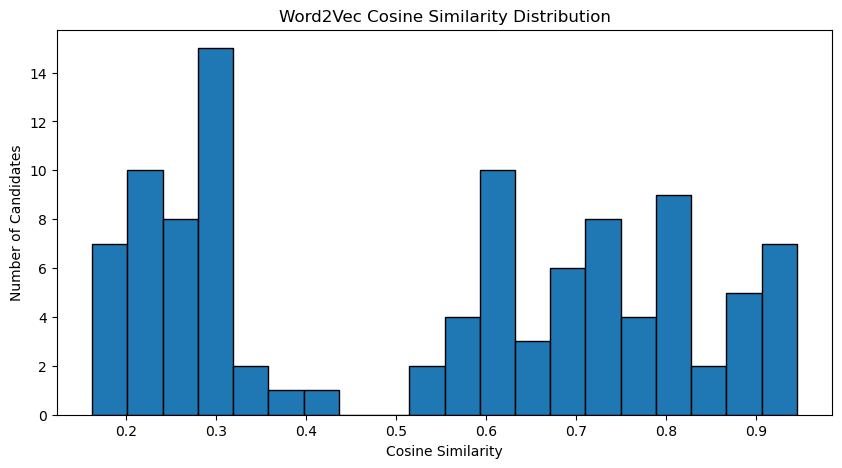

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(
    ranked_candidates["word2vec_similarity"],
    bins=20,
    edgecolor="black"
)

plt.title("Word2Vec Cosine Similarity Distribution")
plt.xlabel("Cosine Similarity")
plt.ylabel("Number of Candidates")

plt.show()

### FastText

In [79]:
fasttext = load("fasttext-wiki-news-subwords-300")

[==================================================] 100.0% 958.5/958.4MB downloaded


In [82]:
def get_fasttext_vector(text, model):
    
    # lowercase
    text = str(text).lower()

    # remove punctuation
    text = re.sub(r"[^a-z\s]", "", text)

    words = word_tokenize(text)

    vectors = []

    for word in words:
        try:
            vectors.append(model[word])
        except KeyError:
            continue

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)

In [83]:
candidate_vectors = np.vstack(
    df["job_title"].apply(
        lambda x: get_fasttext_vector(x, fasttext)
    )
)

In [84]:
candidate_vectors.shape

(104, 300)

In [85]:
query_vector = get_fasttext_vector(
    search_query,
    fasttext
).reshape(1,-1)

In [86]:
fasttext_scores = cosine_similarity(
    candidate_vectors,
    query_vector
).flatten()

In [87]:
df["fasttext_similarity"] = fasttext_scores

fasttext_ranked = (
    df.sort_values(
        "fasttext_similarity",
        ascending=False
    )
    .reset_index(drop=True)
)

In [89]:
df.rename(
    columns={
        "similarity_score": "tfidf_similarity"
    },
    inplace=True
)

comparison = df[
    [
        "job_title",
        "tfidf_similarity",
        "word2vec_similarity",
        "fasttext_similarity"
    ]
].sort_values(
    "fasttext_similarity",
    ascending=False
)

comparison.head(20)

,job_title,tfidf_similarity,word2vec_similarity,fasttext_similarity
2,Aspiring Human Resources Professional,0.612985,0.945019,0.985969
57,Aspiring Human Resources Professional,0.612985,0.945019,0.985969
20,Aspiring Human Resources Professional,0.612985,0.945019,0.985969
45,Aspiring Human Resources Professional,0.612985,0.945019,0.985969
96,Aspiring Human Resources Professional,0.612985,0.945019,0.985969
32,Aspiring Human Resources Professional,0.612985,0.945019,0.985969
16,Aspiring Human Resources Professional,0.612985,0.945019,0.985969
35,Aspiring Human Resources Specialist,0.565568,0.905420,0.972104
59,Aspiring Human Resources Specialist,0.565568,0.905420,0.972104
5,Aspiring Human Resources Specialist,0.565568,0.905420,0.972104
